<a href="https://colab.research.google.com/github/KrishnaKarthikReddy/DLL/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implement CNN on MNITST Dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. HYPERPARAMETERS (Change these to experiment!) ---
LEARNING_RATE = 0.001       # Try: 0.01 (fast/unstable) or 0.0001 (slow/stable)
DROPOUT_RATE = 0.3          # Try: 0.0 to 0.5 (prevents overfitting)
FILTER_SIZE = (3, 3)        # Try: (5, 5) for larger feature detection
NUM_FILTERS = 32            # Try: 16 or 64
STRIDE_VAL = (1, 1)         # Try: (2, 2) to skip pixels and reduce size
PADDING_TYPE = 'same'       # Try: 'valid' (no padding) or 'same' (zeros at edges)
POOL_SIZE = (2, 2)          # Try: (3, 3) for more aggressive downsampling
BATCH_SIZE = 64             # Try: 32 or 128
EPOCHS = 5

# --- 2. DATA AUGMENTATION ---
# This creates new training images by rotating/shifting existing ones
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate images by 10 degrees
    width_shift_range=0.1,  # Randomly shift horizontally
    height_shift_range=0.1, # Randomly shift vertically
    zoom_range=0.1          # Randomly zoom in/out
)

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Fit augmentation to training data
datagen.fit(x_train)

# --- 3. MODEL ARCHITECTURE ---
model = models.Sequential([
    # Conv Layer with manual Stride, Padding, and Filter Size
    layers.Conv2D(NUM_FILTERS, FILTER_SIZE, strides=STRIDE_VAL,
                  padding=PADDING_TYPE, activation='relu', input_shape=(28, 28, 1)),

    # Manual Pooling Size
    layers.MaxPooling2D(pool_size=POOL_SIZE),

    layers.Conv2D(NUM_FILTERS * 2, FILTER_SIZE, activation='relu'),
    layers.MaxPooling2D(pool_size=POOL_SIZE),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Manual Dropout
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(10, activation='softmax')
])

# --- 4. COMPILATION WITH MANUAL LEARNING RATE ---
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. TRAINING ---
# Use flow() to apply data augmentation during training
print(f"Training with LR={LEARNING_RATE}, Dropout={DROPOUT_RATE}...")
model.fit(datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
          epochs=EPOCHS,
          validation_data=(x_test, y_test))

# --- 6. EVALUATION ---
loss, acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with LR=0.001, Dropout=0.3...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.8919 - loss: 0.3455 - val_accuracy: 0.9844 - val_loss: 0.0490
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9596 - loss: 0.1322 - val_accuracy: 0.9884 - val_loss: 0.0311
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9695 - loss: 0.1009 - val_accuracy: 0.9909 - val_loss: 0.0260
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9748 - loss: 0.0826 - val_accuracy: 0.9908 - val_loss: 0.0265
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9778 - loss: 0.0731 - val_accuracy: 0.9925 - val_loss: 0.0231
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9925 - loss: 0.0231

Test Accuracy: 99.25%


# **Apply CNN on your own dataset and find the best parameters for improving model performance.**

In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np

# --- 1. PREPARE YOUR DATASET ---
# Simulating a custom dataset (1000 images, 28x28, 10 classes)
def load_custom_data():
    x = np.random.random((1000, 28, 28, 1))
    y = np.random.randint(0, 10, (1000,))
    return x, y

x_train, y_train = load_custom_data()

# --- 2. DEFINE THE MODEL-BUILDING FUNCTION ---
def build_model(hp):
    model = keras.Sequential()

    # Tune the number of filters in the first Conv layer
    # We test values from 32 to 128
    hp_filters = hp.Int('filters', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    # Tune the number of units in the Dense layer
    hp_units = hp.Int('units', min_value=64, max_value=256, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Tune the Dropout rate
    hp_dropout = hp.Float('dropout', 0.1, 0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Tune the Learning Rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 3. INITIALIZE TUNER ---
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10, # Number of different combinations to try
    directory='my_tuning_dir',
    project_name='cnn_optimization'
)

# --- 4. RUN THE SEARCH ---
tuner.search(x_train, y_train, epochs=5, validation_split=0.2)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimization is complete. The best parameters are:
- Filters: {best_hps.get('filters')}
- Dense Units: {best_hps.get('units')}
- Dropout: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

# --- 5. TRAIN FINAL MODEL ---
model = tuner.hypermodel.build(best_hps)
model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Trial 10 Complete [00h 00m 07s]
val_accuracy: 0.10999999940395355

Best val_accuracy So Far: 0.14499999582767487
Total elapsed time: 00h 00m 52s

The optimization is complete. The best parameters are:
- Filters: 96
- Dense Units: 192
- Dropout: 0.1
- Learning Rate: 0.0001

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.0800 - loss: 2.3344 - val_accuracy: 0.1100 - val_loss: 2.2993
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1063 - loss: 2.3014 - val_accuracy: 0.0750 - val_loss: 2.3217
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1262 - loss: 2.2943 - val_accuracy: 0.1000 - val_loss: 2.3135
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1350 - loss: 2.2836 - val_accuracy: 0.0950 - val_loss: 2.3065
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1488 - loss: 2.2676 - val_accuracy: 0.0800 - val_loss: 2.3125
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1813 - loss: 2.2580 - val_accur

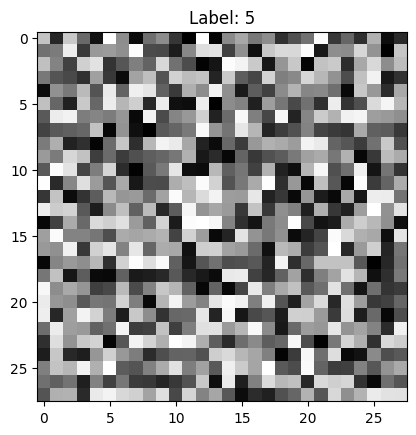

In [ ]:
import matplotlib.pyplot as plt

# Pull the first image, squeeze out the channel dimension for plotting
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os

# ================================
# 2. DATASET PATH
# ================================
# Change this path to your dataset folder
data_dir = "dataset"

img_size = (128, 128)
batch_size = 32

# ================================
# 3. DATA PREPROCESSING + AUGMENTATION
# ================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# ================================
# 4. BUILD CNN MODEL
# ================================
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),   # Prevent overfitting

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# ================================
# 5. COMPILE MODEL (TUNED LR)
# ================================
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# 6. EARLY STOPPING
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ================================
# 7. TRAIN MODEL
# ================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

# ================================
# 8. EVALUATE MODEL
# ================================
loss, accuracy = model.evaluate(val_data)
print(f"\nValidation Accuracy: {accuracy*100:.2f}%")

# ================================
# 9. PLOT RESULTS
# ================================
# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# ================================
# 10. SAVE MODEL
# ================================
model.save("cnn_model.h5")

# ================================
# 11. PREDICT ON NEW IMAGE
# ================================
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "test.jpg"  # change to your image

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Class 1")
else:
    print("Class 2")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset'